# Country boundaries — raw vs STAC folder vs cloud

Checks that the Natural Earth country polygons are the same in the three places they live:

1. **Raw**: `P:\...\Data_Vivian\ne_10m_admin_0_countries.shp` (original shapefile)
2. **STAC folder**: `P:\...\Data_Vivian\stac\country_boundaries\parquet\country_boundaries.parquet` (GeoParquet produced by `notebooks/19_country_boundaries.ipynb`)
3. **Cloud**: the GeoParquet found through the public STAC catalog (`gca-stac-7`, collection `country_boundaries`)

The layer is small (258 polygons), so all three are read completely, plotted side by side and compared attribute by attribute and geometry by geometry.

Environment: `environment_exploration.yml` (Miniforge).

In [5]:
from pathlib import Path
from posixpath import join as urljoin

import fsspec
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import pyarrow.parquet as pq
import pystac_client

## 1) Locations

In [6]:
data_vivian = Path(r"P:\11209117-041-ipdc-egypt-swi\data\IntDeltaPlatform_QGA\Data_Vivian")
raw_path = data_vivian / "ne_10m_admin_0_countries.shp"
stac_folder_path = data_vivian / "stac" / "country_boundaries" / "parquet" / "country_boundaries.parquet"

gcs_protocol = "https://storage.googleapis.com"
catalog_url = urljoin(gcs_protocol, "gca-data-public", "gca", "gca-stac-7", "catalog.json")
collection_id = "country_boundaries"

for p in (raw_path, stac_folder_path):
    print(p.is_file(), p)

True P:\11209117-041-ipdc-egypt-swi\data\IntDeltaPlatform_QGA\Data_Vivian\ne_10m_admin_0_countries.shp
True P:\11209117-041-ipdc-egypt-swi\data\IntDeltaPlatform_QGA\Data_Vivian\stac\country_boundaries\parquet\country_boundaries.parquet


## 2) Find the data through the STAC catalog

In [7]:
catalog = pystac_client.Client.open(catalog_url)
collection = next((c for c in catalog.get_children() if c.id == collection_id), None)
if collection is None:
    raise LookupError(f"Collection {collection_id} not found in {catalog_url}")

items = list(collection.get_items())
print("Collection:", collection.id, "|", collection.title)
print("Items:", [i.id for i in items])

item = items[0]
assert collection_id in item.assets["data"].href, f"Unexpected item href: {item.assets['data'].href}"
cloud_href = item.assets["data"].href
print("Cloud GeoParquet:", cloud_href)
print("Item bbox:", item.bbox)
print("Item properties:", list(item.properties))
print("table:row_count:", item.properties.get("table:row_count"))

c:\Users\fuentesm\AppData\Local\miniforge3\envs\gca-exploration\Lib\site-packages\pystac_client\client.py:191: NoConformsTo: Server does not advertise any conformance classes.
  warnings.warn(NoConformsTo())


Collection: country_boundaries | Admin 0 – Countries
Items: ['country_boundaries']
Cloud GeoParquet: https://storage.googleapis.com/gca-data-public/gca/country_boundaries/country_boundaries.parquet
Item bbox: [-180.0, -90.0, 180.0, 83.634101]
Item properties: ['title', 'description', 'table:row_count', 'table:columns', 'deltares:item_key', 'created', 'datetime', 'proj:code']
table:row_count: 258


c:\Users\fuentesm\AppData\Local\miniforge3\envs\gca-exploration\Lib\site-packages\pystac_client\collection_client.py:149: FallbackToPystac: Falling back to pystac. This might be slow.
  root._warn_about_fallback("ITEM_SEARCH")


## 3) Read the three sources

In [8]:
layers = {}
layers["raw (P:)"] = gpd.read_file(raw_path, engine="pyogrio")
layers["stac folder (P:)"] = gpd.read_parquet(stac_folder_path)
import io
import requests

print("Reading cloud file:", cloud_href)
cloud_bytes = requests.get(cloud_href, timeout=120).content
layers["cloud (catalog)"] = gpd.read_parquet(io.BytesIO(cloud_bytes))
print(f"downloaded {len(cloud_bytes)} bytes")

for name, gdf in layers.items():
    print(name, len(gdf.columns), "columns | NE_ID-like:", [c for c in gdf.columns if c.upper() == "NE_ID"])

# Drop the covering column and put the rows in the same order
layers = {
    name: gdf.drop(columns="bbox", errors="ignore").sort_values("NE_ID").reset_index(drop=True)
    for name, gdf in layers.items()
}

pd.DataFrame(
    {
        name: {
            "rows": len(gdf),
            "columns": len(gdf.columns),
            "crs": gdf.crs.to_string(),
            "NE_ID unique": gdf["NE_ID"].is_unique,
            "total POP_EST": int(gdf["POP_EST"].sum()),
            "bounds": tuple(round(v, 3) for v in gdf.total_bounds),
        }
        for name, gdf in layers.items()
    }
).T

Reading cloud file: https://storage.googleapis.com/gca-data-public/gca/country_boundaries/country_boundaries.parquet
downloaded 5945458 bytes
raw (P:) 169 columns | NE_ID-like: ['NE_ID']
stac folder (P:) 169 columns | NE_ID-like: ['NE_ID']
cloud (catalog) 169 columns | NE_ID-like: ['NE_ID']


,rows,columns,crs,NE_ID unique,total POP_EST,bounds
raw (P:),258,169,EPSG:4326,True,7677059722,"(-180.0, -90.0, 180.0, 83.634)"
stac folder (P:),258,169,EPSG:4326,True,7677059722,"(-180.0, -90.0, 180.0, 83.634)"
cloud (catalog),258,169,EPSG:4326,True,7677059722,"(-180.0, -90.0, 180.0, 83.634)"


## 4) Plot

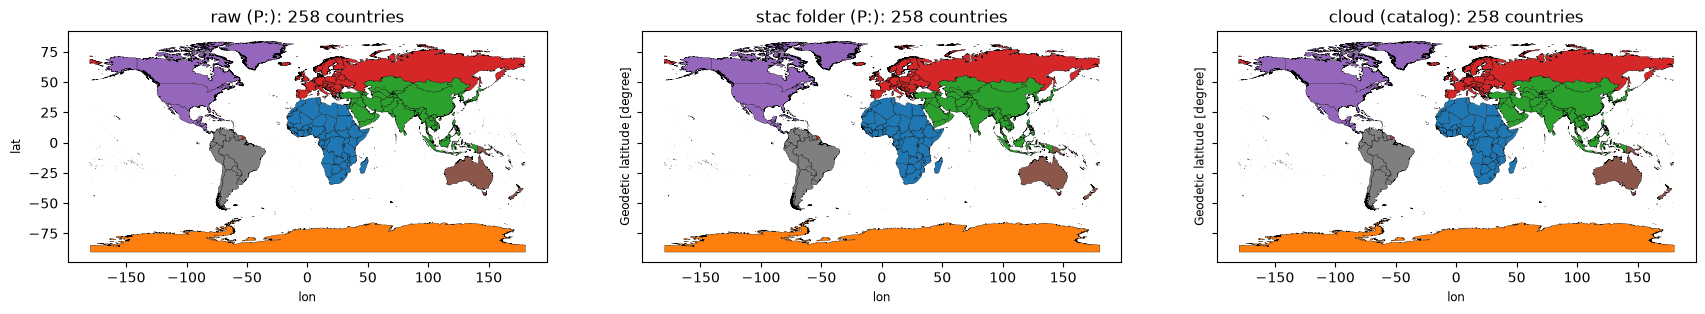

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(21, 5), sharex=True, sharey=True)
for ax, (name, gdf) in zip(axes, layers.items()):
    gdf.plot(ax=ax, column="CONTINENT", cmap="tab10", edgecolor="black", linewidth=0.2)
    ax.set_title(f"{name}: {len(gdf)} countries")
    ax.set_xlabel("lon")
axes[0].set_ylabel("lat")
plt.show()

## 5) Compare attributes and geometries

In [10]:
names = list(layers)
ref = names[0]
attrs = [c for c in layers[ref].columns if c != "geometry"]

results = []
for other in names[1:]:
    a, b = layers[ref], layers[other]
    same_shape = a.shape == b.shape and list(a.columns) == list(b.columns)
    attrs_equal = same_shape and pd.DataFrame(a[attrs]).equals(pd.DataFrame(b[attrs]))
    n_geom_diff = int((~a.geometry.geom_equals_exact(b.geometry, tolerance=0)).sum()) if same_shape else None
    results.append({
        "comparison": f"{ref} vs {other}",
        "same rows/columns": same_shape,
        "same CRS": a.crs == b.crs,
        "identical attributes": attrs_equal,
        "different geometries": n_geom_diff,
        "identical": bool(attrs_equal and n_geom_diff == 0),
    })
display(pd.DataFrame(results))

if all(r["identical"] for r in results):
    print("OK: raw, stac folder and cloud contain exactly the same countries.")
else:
    print("MISMATCH: see the table above.")

,comparison,same rows/columns,same CRS,identical attributes,different geometries,identical
0,raw (P:) vs stac folder (P:),True,True,True,0,True
1,raw (P:) vs cloud (catalog),True,True,True,0,True


OK: raw, stac folder and cloud contain exactly the same countries.
